# Assignment 2 — Discrete and Continuous Probability Models

**Course:** Statistics and Data Analysis for Engineers (STA1)

**Group members:** _(add names here)_

## Table of contents

1. [Part 3 — Uniform and normal models](#part3)
2. [Part 4 — Service restoration: an exponential working model](#part4)

Only methods from Sessions 3–4 are used: continuous distributions (uniform, normal, exponential),
SciPy `loc`/`scale` parameterisation, and graphical model checks (histogram with fitted PDF,
QQ-plot, empirical vs. fitted CDF).

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA = "data/"

concrete = pd.read_csv(DATA + "assignment02_concrete_strength.csv")   # Part 3
repairs = pd.read_csv(DATA + "assignment02_service_repairs.csv")     # Part 4

print(f"concrete: {concrete.shape[0]} rows x {concrete.shape[1]} columns")
print(f"repairs: {repairs.shape[0]} rows x {repairs.shape[1]} columns")

concrete: 160 rows x 2 columns
repairs: 180 rows x 2 columns


<a id="part3"></a>
# Part 3 — Uniform and normal models

### Sensor polling delay: uniform

> A monitoring device polls a sensor once every 12 seconds. An event is assumed to occur at a
> random point in the cycle, so the delay $D$ until the next poll is modelled as
> $D \sim \mathrm{Uniform}(0, 12)$.

#### a)

> Create the SciPy model using the correct location and scale. Plot its PDF and CDF and explain
> the support, constant density, and why $P(D=d)=0$.

SciPy's `uniform` is parameterised by `loc` $=a$ and `scale` $=b-a$, so $D \sim U(0,12)$ needs
`loc=0, scale=12`:
$$f_D(d) = \frac{1}{b-a} = \frac{1}{12}, \;\; a \le d \le b; \qquad
F_D(d) = \frac{d-a}{b-a} = \frac{d}{12}, \;\; a \le d \le b$$

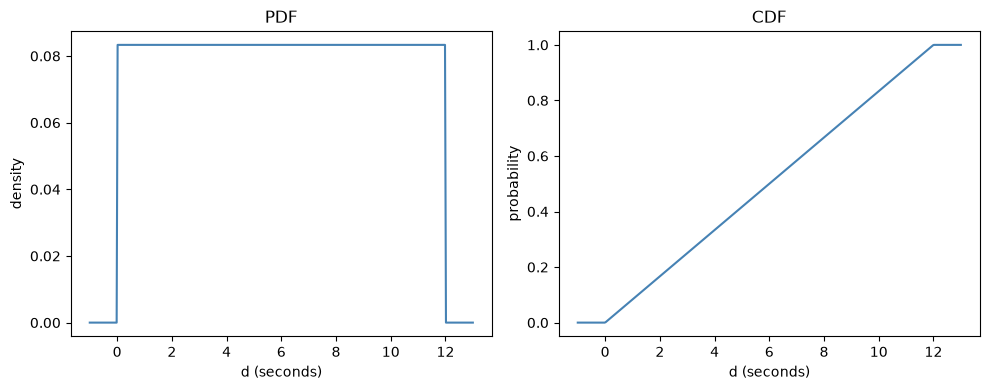

In [2]:
a, b = 0, 12
D = stats.uniform(loc=a, scale=b - a)

d = np.linspace(-1, 13, 400)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(d, D.pdf(d), color="steelblue")
axes[0].set_xlabel("d (seconds)")
axes[0].set_ylabel("density")
axes[0].set_title("PDF")

axes[1].plot(d, D.cdf(d), color="steelblue")
axes[1].set_xlabel("d (seconds)")
axes[1].set_ylabel("probability")
axes[1].set_title("CDF")

plt.tight_layout()
plt.show()

**Support.** $\mathrm{supp}(D) = [0, 12]$ seconds — the delay can fall anywhere in the 12-second
polling cycle, never negative or longer than a full cycle.

**Constant density.** The PDF is flat at $1/12 \approx 0.083$ across $[0,12]$ because the event
is equally likely to occur at any point in the cycle: equal-length subintervals of $[0,12]$ carry
equal probability.

**Why $P(D=d)=0$.** For a continuous variable, probability is *area* under the density; a single
point $d$ has zero width, so it contributes zero area no matter how "likely" that value looks on
the curve. This does not mean $d$ is impossible to observe — only that no single value carries
positive probability mass.

#### b)

> Calculate $P(D \le 3)$, $P(4 < D < 9)$, $P(D > 10)$, the mean, standard deviation, and 95th
> percentile.

For $a \le c < d \le b$: $P(c<D<d) = F(d)-F(c) = \dfrac{d-c}{b-a}$, and
$$E[D] = \frac{a+b}{2}, \qquad Var(D) = \frac{(b-a)^2}{12}$$

In [3]:
P_Dle3 = D.cdf(3)
P_4lt_lt9 = D.cdf(9) - D.cdf(4)
P_Dgt10 = D.sf(10)
mean_D, sd_D = D.mean(), D.std()
p95_D = D.ppf(0.95)

print(f"P(D<=3)     = {P_Dle3:.4f}")
print(f"P(4<D<9)    = {P_4lt_lt9:.4f}")
print(f"P(D>10)     = {P_Dgt10:.4f}")
print(f"mean        = {mean_D:.4f} s")
print(f"sd          = {sd_D:.4f} s")
print(f"95th pct    = {p95_D:.4f} s")

P(D<=3)     = 0.2500
P(4<D<9)    = 0.4167
P(D>10)     = 0.1667
mean        = 6.0000 s
sd          = 3.4641 s
95th pct    = 11.4000 s


**Interpretation.** A quarter of delays are 3 seconds or less; about 42 % fall strictly between
4 and 9 seconds; and about a sixth exceed 10 seconds. The mean delay is 6 s (the cycle's
midpoint), with a standard deviation of about 3.46 s; 95 % of delays are under 11.4 s.

### Concrete strength: normal working model

> The file `assignment02_concrete_strength.csv` contains 160 compressive-strength measurements.
> Treat the generating parameters as unknown.

#### a)

> Report $n$, mean, median, and sample standard deviation. Fit $N(\hat\mu, \hat\sigma^2)$ and
> explain why SciPy receives $\hat\sigma$, not $\hat\sigma^2$, as `scale`.

In [4]:
n_c = len(concrete)
mu_hat = concrete["strength_mpa"].mean()
median_c = concrete["strength_mpa"].median()
sigma_hat = concrete["strength_mpa"].std()   # sample sd, ddof=1 by default

print(f"n      = {n_c}")
print(f"mean   = {mu_hat:.2f} MPa")
print(f"median = {median_c:.2f} MPa")
print(f"sd     = {sigma_hat:.2f} MPa")

n      = 160
mean   = 42.49 MPa
median = 42.38 MPa
sd     = 4.34 MPa


**Fitted model.** $X \sim N(\hat\mu, \hat\sigma^2)$ with $\hat\mu \approx 42.49$ MPa and
$\hat\sigma^2 \approx 18.86\ \text{MPa}^2$ (i.e. $\hat\sigma \approx 4.34$ MPa).

**Why `scale` is $\hat\sigma$, not $\hat\sigma^2$.** In the mathematical notation $N(\mu,\sigma^2)$
the second parameter is the *variance*. SciPy's `norm`, however, takes `scale`, which is the
*standard deviation* $\sigma$ — the spread expressed on the same scale (MPa) as the data itself.
Passing the variance in its place would make the fitted curve far too wide.

In [5]:
normal_model = stats.norm(loc=mu_hat, scale=sigma_hat)
print(f"fitted N({mu_hat:.2f}, {sigma_hat**2:.2f})")

fitted N(42.49, 18.86)


#### b)

> Plot a density histogram with the fitted PDF and create a normal QQ-plot. Discuss symmetry,
> tails, unusual observations, and model adequacy.

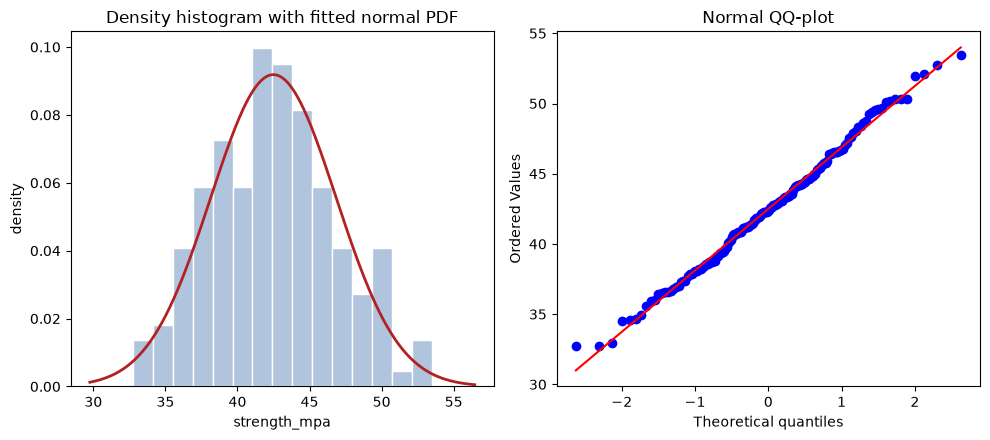

In [6]:
x_grid = np.linspace(concrete["strength_mpa"].min() - 3, concrete["strength_mpa"].max() + 3, 300)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].hist(concrete["strength_mpa"], bins=15, density=True, color="lightsteelblue",
             edgecolor="white")
axes[0].plot(x_grid, normal_model.pdf(x_grid), color="firebrick", lw=2)
axes[0].set_xlabel("strength_mpa")
axes[0].set_ylabel("density")
axes[0].set_title("Density histogram with fitted normal PDF")

stats.probplot(concrete["strength_mpa"], dist="norm", plot=axes[1])
axes[1].set_title("Normal QQ-plot")

plt.tight_layout()
plt.show()

In [7]:
skew = stats.skew(concrete["strength_mpa"])
exkurt = stats.kurtosis(concrete["strength_mpa"])
q1, q3 = concrete["strength_mpa"].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_out = ((concrete["strength_mpa"] < lo) | (concrete["strength_mpa"] > hi)).sum()

print(f"skewness          = {skew:.3f}")
print(f"excess kurtosis   = {exkurt:.3f}")
print(f"1.5xIQR outliers  = {n_out}")

skewness          = 0.136
excess kurtosis   = -0.335
1.5xIQR outliers  = 0


**Symmetry.** Skewness is about 0.14, close to 0, and the mean (42.49) sits almost on top of the
median (42.38) — the distribution is close to symmetric, matching the roughly straight-line QQ
pattern.

**Tails.** Excess kurtosis is about −0.34 (slightly negative), so the tails are a touch lighter
than a normal distribution's. This shows up in the QQ-plot as the extreme points bending gently
*inward* rather than curving away from the line, and no point lies outside the 1.5×IQR fences.

**Unusual observations.** None — there are no 1.5×IQR outliers, and the histogram shows a single,
roughly bell-shaped mode with no gaps or clusters.

**Model adequacy.** A normal working model looks reasonable here: unimodal, close to symmetric,
no heavy tails and no unusual points.

#### c)

> From the fitted model, calculate $P(X<35)$, $P(38<X<46)$, the 95th percentile, and the
> $z$-score of 35 MPa. Compare the first two model probabilities with empirical proportions.

In [8]:
P_Xlt35 = normal_model.cdf(35)
P_38lt_lt46 = normal_model.cdf(46) - normal_model.cdf(38)
p95_X = normal_model.ppf(0.95)
z_35 = (35 - mu_hat) / sigma_hat

emp_lt35 = (concrete["strength_mpa"] < 35).mean()
emp_38_46 = ((concrete["strength_mpa"] > 38) & (concrete["strength_mpa"] < 46)).mean()

print(f"model  P(X<35)      = {P_Xlt35:.4f}")
print(f"model  P(38<X<46)   = {P_38lt_lt46:.4f}")
print(f"model  95th pct     = {p95_X:.2f} MPa")
print(f"z-score of 35 MPa   = {z_35:.4f}")
print()
print(f"empirical P(X<35)     = {emp_lt35:.4f}")
print(f"empirical P(38<X<46)  = {emp_38_46:.4f}")

model  P(X<35)      = 0.0422
model  P(38<X<46)   = 0.6399
model  95th pct     = 49.64 MPa
z-score of 35 MPa   = -1.7256

empirical P(X<35)     = 0.0437
empirical P(38<X<46)  = 0.6375


**Interpretation.** The fitted model puts about 4.2 % of strengths below 35 MPa and about 64.0 %
between 38 and 46 MPa — versus 4.4 % and 63.8 % observed empirically, a very close match. 95 % of
strengths are predicted to fall below about 49.6 MPa. A specimen at 35 MPa has $z \approx -1.73$,
i.e. about 1.73 standard deviations below the fitted mean, consistent with it being an
uncommon but unremarkable low reading rather than an outlier. The close agreement between model
and empirical probabilities supports the model-adequacy conclusion from (b).

<a id="part4"></a>
# Part 4 — Service restoration: an exponential working model

> The file `assignment02_service_repairs.csv` contains 180 restoration times from independent
> service incidents. Treat the rate as unknown.

## a)

> Report $n$, mean, median, sample standard deviation, minimum, and maximum. Plot a density
> histogram and describe the shape.

In [9]:
n_r = len(repairs)
mean_r = repairs["repair_time_min"].mean()
median_r = repairs["repair_time_min"].median()
sd_r = repairs["repair_time_min"].std()
min_r = repairs["repair_time_min"].min()
max_r = repairs["repair_time_min"].max()

print(f"n      = {n_r}")
print(f"mean   = {mean_r:.2f} min")
print(f"median = {median_r:.2f} min")
print(f"sd     = {sd_r:.2f} min")
print(f"min    = {min_r:.2f} min")
print(f"max    = {max_r:.2f} min")

n      = 180
mean   = 69.80 min
median = 49.34 min
sd     = 67.43 min
min    = 1.11 min
max    = 410.66 min


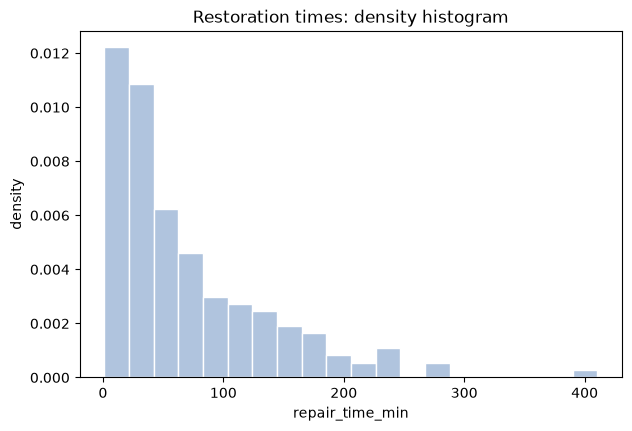

In [10]:
plt.figure(figsize=(7, 4.5))
plt.hist(repairs["repair_time_min"], bins=20, density=True, color="lightsteelblue",
         edgecolor="white")
plt.xlabel("repair_time_min")
plt.ylabel("density")
plt.title("Restoration times: density histogram")
plt.show()

**Shape.** The histogram is tallest near zero and decays steadily to the right — strongly
**right-skewed**, with no negative values (min 1.11 min) and a long tail out to 410.66 min. The
mean (69.80 min) sits well above the median (49.35 min), the usual signature of this skew, and
the standard deviation (67.43 min) is close in size to the mean itself — exactly the pattern a
waiting-time process tends to produce.

## b)

> Fit an exponential model using $\hat\lambda = 1/\bar x$. State its fitted rate, mean, variance,
> and SciPy scale and add the fitted PDF to the histogram.

$$\hat\lambda = \frac{1}{\bar x}, \qquad \text{SciPy } \texttt{scale} = \frac{1}{\hat\lambda} = \bar x$$

In [11]:
lambda_hat = 1 / mean_r
expon_scale = 1 / lambda_hat   # = mean_r

exp_model = stats.expon(scale=expon_scale)

print(f"lambda_hat   = {lambda_hat:.5f} per minute")
print(f"scale        = {expon_scale:.2f} min")
print(f"fitted mean  = {exp_model.mean():.2f} min")
print(f"fitted var   = {exp_model.var():.2f} min^2")

lambda_hat   = 0.01433 per minute
scale        = 69.80 min
fitted mean  = 69.80 min
fitted var   = 4871.85 min^2


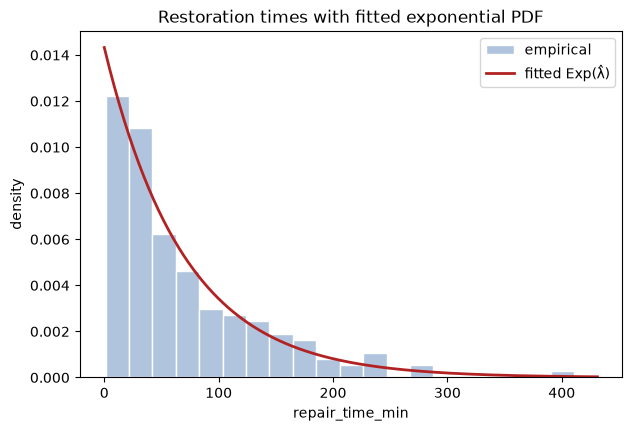

In [12]:
t_grid = np.linspace(0, repairs["repair_time_min"].max() * 1.05, 300)

plt.figure(figsize=(7, 4.5))
plt.hist(repairs["repair_time_min"], bins=20, density=True, color="lightsteelblue",
         edgecolor="white", label="empirical")
plt.plot(t_grid, exp_model.pdf(t_grid), color="firebrick", lw=2, label="fitted Exp(λ̂)")
plt.xlabel("repair_time_min")
plt.ylabel("density")
plt.title("Restoration times with fitted exponential PDF")
plt.legend()
plt.show()

**Interpretation.** The fitted rate is about 0.0143 restorations completed per minute of elapsed
repair time. By construction, the fitted mean (69.80 min) exactly matches the sample mean; the
fitted variance is about 4871.8 min². The fitted PDF traces the same decaying shape as the
histogram: highest density near zero, falling off toward the long tail.

## c)

> Compare empirical and fitted distributions using an empirical CDF with fitted CDF or an
> exponential QQ-plot. Discuss model strengths and limitations.

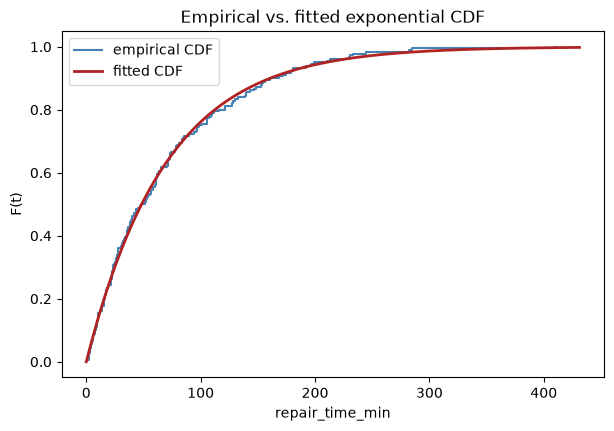

In [13]:
sorted_t = np.sort(repairs["repair_time_min"])
ecdf_y = np.arange(1, n_r + 1) / n_r

plt.figure(figsize=(7, 4.5))
plt.step(sorted_t, ecdf_y, where="post", color="steelblue", label="empirical CDF")
plt.plot(t_grid, exp_model.cdf(t_grid), color="firebrick", lw=2, label="fitted CDF")
plt.xlabel("repair_time_min")
plt.ylabel("F(t)")
plt.title("Empirical vs. fitted exponential CDF")
plt.legend()
plt.show()

**Strengths.** The fitted CDF tracks the empirical step function closely across almost the whole
range — the exponential model captures the strong right skew, the near-zero minimum, and the long
tail well, without needing extra parameters.

**Limitations.** The exponential model forces the density to be *highest at $t=0$*, i.e. it treats
an instant restoration as the single most likely outcome. Real repairs typically need at least
some minimum time for diagnosis and travel, so a small positive "floor" is plausible even though
the data's minimum (1.11 min) happens to sit close to zero. The model also assumes a **constant**
completion rate throughout a repair (see (e)); if repairs instead get easier to finish the longer
they run — or harder — the exponential shape would systematically over- or under-state the tail.

## d)

> Calculate and interpret $P(T \le 30)$, $P(T>120)$, the median, and the 90th percentile.
> Compare the two model probabilities with empirical proportions.

In [14]:
P_Tle30 = exp_model.cdf(30)
P_Tgt120 = exp_model.sf(120)
median_T = exp_model.median()
p90_T = exp_model.ppf(0.90)

emp_le30 = (repairs["repair_time_min"] <= 30).mean()
emp_gt120 = (repairs["repair_time_min"] > 120).mean()

print(f"model      P(T<=30)   = {P_Tle30:.4f}")
print(f"model      P(T>120)   = {P_Tgt120:.4f}")
print(f"model      median     = {median_T:.2f} min")
print(f"model      90th pct   = {p90_T:.2f} min")
print()
print(f"empirical  P(T<=30)   = {emp_le30:.4f}")
print(f"empirical  P(T>120)   = {emp_gt120:.4f}")

model      P(T<=30)   = 0.3494
model      P(T>120)   = 0.1792
model      median     = 48.38 min
model      90th pct   = 160.72 min

empirical  P(T<=30)   = 0.3611
empirical  P(T>120)   = 0.2000


**Interpretation.** The model predicts about 34.9 % of repairs finish within 30 minutes (observed:
36.1 %) and about 17.9 % take more than 120 minutes (observed: 20.0 %). Both are reasonably close,
though the model slightly *understates* the long tail — a mild version of the limitation noted in
(c). The fitted median is 48.38 min, close to the sample median (49.35 min); 90 % of restorations
are predicted to finish within about 160.7 min.

## e)

> Calculate $P(T>150 \mid T>60)$ as both a ratio of survival probabilities and the probability of
> waiting an additional 90 minutes. Explain the memoryless and constant-rate assumptions.

$$P(T>150 \mid T>60) = \frac{P(T>150)}{P(T>60)} = \frac{S(150)}{S(60)}$$

By the memoryless property of the exponential distribution,
$P(T>s+t \mid T>s) = P(T>t)$, so with $s=60$ and $t=90$ this also equals $P(T>90)$ directly.

In [15]:
ratio_form = exp_model.sf(150) / exp_model.sf(60)
direct_form = exp_model.sf(90)

print(f"S(150)/S(60)      = {ratio_form:.4f}")
print(f"P(T>90) directly  = {direct_form:.4f}")

S(150)/S(60)      = 0.2754
P(T>90) directly  = 0.2754


**Interpretation.** Both routes give the same value, about 0.2754. Having already waited 60
minutes without a restoration tells us nothing about how much longer it will take — the "clock
resets," and the extra wait behaves exactly like a fresh $T$.

**Why this holds.** The memoryless property only follows because the exponential model assumes a
**constant restoration rate** $\lambda$ throughout a repair: the chance of finishing in the next
instant never depends on how long the technician has already been working. In practice this could
fail — e.g. if repairs still open after an hour tend to be genuinely harder cases (rate
decreasing with elapsed time), or if most of the diagnosis is already done and completion becomes
more likely the longer it runs (rate increasing). Either would break the constant-rate assumption
and, with it, the memoryless property.